# NGC 1300 Nebular Spectroscopy

In this notebook, we will walk through how to display, fit, and analyze emission spectra from nebular regions in NGC 1300. Throughout the notebook, there will be semi-complete blocks of code which you will have to fill in. You will be introduced to the methods used before needing to implement them yourself. 

Comments will be included throughout the code to explain what each line does. These will be denoted with either red strings (' ') or #

Please do not hesitate to ask for help along the way! Now let's get started!

# Part 1

## Imports
Every notebook should start with your imports. This will make all of the packages and tools you need available from the very start of your code. 

In [79]:
import numpy as np # all of the basic math/computation tools you need
import matplotlib.pyplot as plt # all of the plotting tools you need
import astropy # astronomy-specific package
from astropy.io import fits # allows you to easily open fits files

## Opening the spectra
Now that we have the necessary tools for now, let's access and open the data so we will be working with. If this notebook is stored within OneDrive, the files in the folder should be accessible and there is no need to download them. Otherwise, you will need to change the file paths used in this notebook. 

Fits files are opened as Header Data Units (HDU). This HDU contains the header (all of the information about the coordinate system, units, observing techniques, etc.) and the data. 

For this fits file, there are 2 HDUs: the first one containing the flux values, and the second containing the wavelength information. The organization of this file is outline in the associated ReadMe, which is available in the OneDrive folder. Formatting varies a lot between datasets, so having a ReadMe file is important. 

Let's open the data.

In [80]:
# The spectra for NGC1300 are located in the file named 'NGC1300_VorSpectra.fits'
#hdu=fits.open('Polaris-2026/spectra/NGC1300_VorSpectra.fits')
hdu=fits.open('NGC1300_VorSpectra.fits')

# Here's how we can access the flux information
flux=hdu[1].data['SPEC']


# and the wavelength
wave_log=hdu[2].data['LOGLAM']

# The file has log(wavelength) so we will undo that to put it back to linear
wave=np.exp(wave_log)
print("Data for NGC1300 has been read.")

Data for NGC1300 has been read.


Okay great, now we've read the data and are ready to play around with it. Let's see what it looks like.

In [81]:
print('Shape of Flux:',np.shape(flux))
print('Shape of Wave:',np.shape(wave))

Shape of Flux: (1478, 3835)
Shape of Wave: (3835,)


This tells us that there are 1478 regions with spectra in this file. Each spectra consists of 3835 wavelengths and 3835 corresponding flux values. We will NOT be dealing with all 1478 of those regions, we will just focus on two: 961 and 684. To access these, we need to 'index' the flux array for the index number we want with flux[_ ID _]

Let's define a variable so we can keep things straight and not remember two random numbers.

In [104]:
# These are the region numbers that we will be using throughout the project
region1=961
region2=684
print(flux[961])
print(wave[961])

print(flux[684])
print(wave[684])

[388.09455826 396.172586   406.17867726 ... 415.1289987  395.42421822
 378.03214836]
5663.500316192432
[538.11497434 604.79737443 687.39552858 ... 323.69782954 323.19242782
 318.33054794]
5407.806210836271


## Plotting the spectra

Now for the fun part, we get to plot the data! 

You can change the properties of the plotted line using keywords like:

linewidth (or lw): changes the width of the line, default is 1.5

color: can be a matplotlib default color or an xkcd color name written as a string like 
'xkcd:red' https://xkcd.com/color/rgb/

These are the most common, but there are many more customizations in the matplotlib documentation: 
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

To save the image, we include 'plt.savefig()' as the final line before 'plt.show()'. 

### Play around with some of these features to get a full spectrum of Region 1 you are really happy with! Have fun with it!

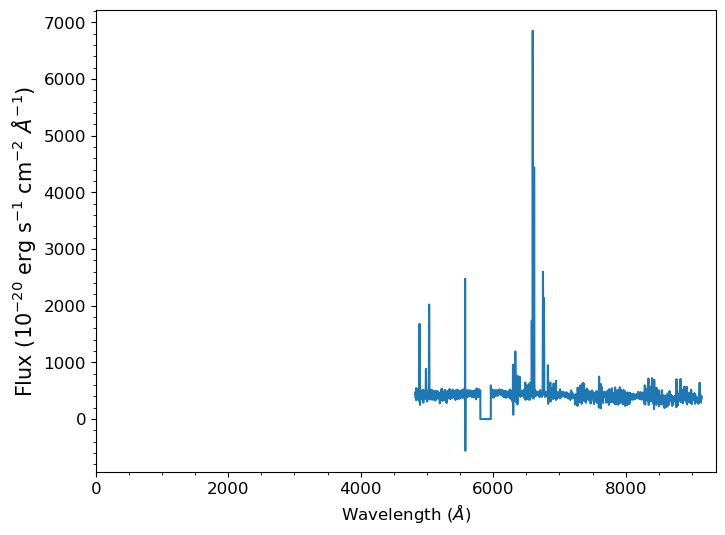

In [83]:
plt.figure(figsize=(8,6))
plt.plot(wave, flux[region1])
 #plot a line given x, y
plt.xlim(0, )
plt.gca().minorticks_on()
plt.gca().tick_params(labelsize=12)
plt.xlabel(r'Wavelength ($\AA$)',fontsize=12)
plt.ylabel(r'Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)',fontsize=15)
plt.savefig('__filename__',bbox_inches='tight') # including no file path here saves the figure in the same location as the notebook.
    # bbox_inches controls how much white space is around the saved figure. I always include this
plt.show()


# Part 2

## Identifying emission lines

In this spectra, it is pretty clear where the emission lines are, but how do we know what type of gas they come from? The short answer is that you typically have a list of a whole bunch of emission lines that are commonly seen. So you always just look for those. 

Here is a dictionary linking the emission line to its wavelength (in Angstroms). 

In [84]:
em_lines={'Hb':4861,'OIII_1':4959,'OIII_2':5007,'OI':6300,'Ha':6562,'NII_1':6548,'NII_2':6584,'SII_1':6717,'SII_2':6731}


Some of the emission lines have a '_1' and '_2' in them. This means that it's a doublet. They are produced by the same energy transition of the electron, but the wavelength changes because of the electron spin. So their typical strength is set by quantum mechanics. We almost always combine their strengths because of this.

There are also emission lines produced by the atomosphere of Earth. These are also at extremely predictable wavelengths (and their redshift is zero) so we just need to mask those out, or ignore them in the analysis. 

Here are a couple big ones in the wavelength range we care about:

In [85]:
sky_lines=[5577,6300,6363]

Now that we've identified where the emission lines are expected to be, We can plot and label them on our figure from before. 
You may have notices that there is quite a large spread in wavelength for the prominent emission lines, but they do come in convenient groups. So we'll also make a subplot so that we can display two sections of the spectra at the same time. 

In this block, we will build code to make a really pretty spectrum of Region 1 with all emission lines labeled. Use whatever customizations you want to make this how you want it to be.

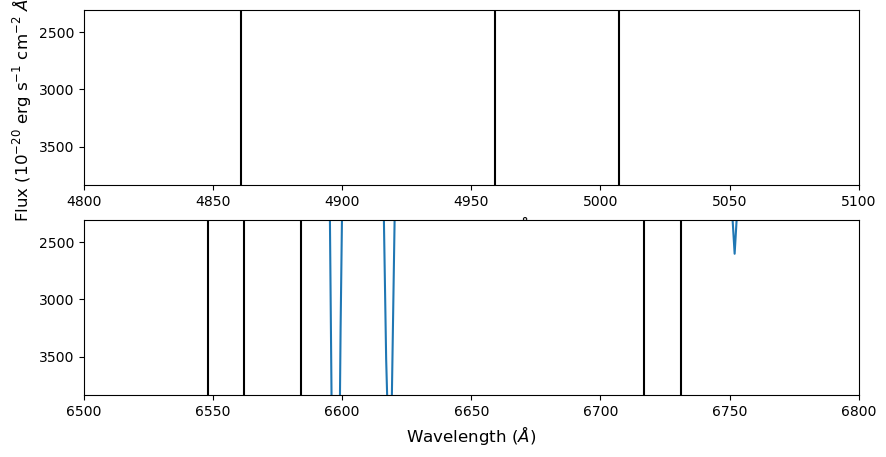

In [97]:
fig,axs=plt.subplots(2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region1])
    for l,line in enumerate(em_lines):
        ax.axvline(em_lines[line],label=f'{line}',color='k')
        # ax.text()
    for s in sky_lines:
        ax.axvline(s,color='gray')
    ax.set_ylim(y,)
    ax.set_xlabel('Wavelength ($\AA$)',fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)',fontsize=12)
plt.show()

Why don't our vertical lines match with the observed emission?

Well, the galaxy we're looking at is pretty far away. It's very close in the grand scheme of things, but it's far enough to cause a redshift in the emission. The x axis of this spectrum is actually the "observed" wavelength. What we really want is the "emitted" wavelength or "rest" wavelength before the light was redshifted. 

Let's write a function that will correct for the redshift of the galaxy. 

In [87]:
def lam_obs(lam_rest,z):
    ''' convert a rest wavelength to the observed wavelength at a given redshift '''
    lam=z*lam_rest+lam_rest
    return lam


Amazing. We can now convert the rest wavelength of the emission lines to the observed wavelength in the spectrum. 

But we actually don't know the redshift of the galaxy. Google could tell us, but we would need to keep googling things if we ever wanted to change the galaxy we look at. So let's write some code to convert the distance of the galaxy (which is something that has been calculated precisely for every PHANGS galaxy) to the redshift. 

In [88]:
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import FlatLambdaCDM
u.add_enabled_units(cu)

D=21*u.Mpc # Distance to NGC 1300 from the PHANGS sample table
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)
z=D.to(cu.redshift,cu.with_redshift(cosmo, distance="comoving"))
print(f'Distance = {D}, z = {z.value}')


Distance = 21.0 Mpc, z = 0.0049088217264950055


Now that we have that, let's retry the plot. 

Here, the code is written so that the emission line wavelengths are redshifted to the distance of the galaxy, observed wavelength on the x axis. Try making a plot with rest wavelength on the x axis by correcting the observed wavelength array instead of the emission lines. 

Spectrum of Region 1 (with Emission Lines Labeled)


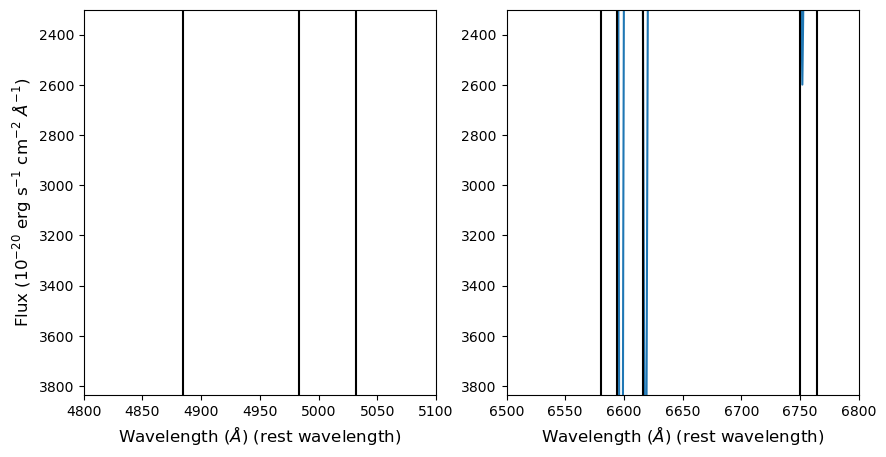

In [103]:
fig,axs=plt.subplots(1,2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region1])
    for l,line in enumerate(em_lines):
        ax.axvline(lam_obs(em_lines[line],z),label=f'{line}',color='k') # correcting for redshift
    for s in sky_lines:
        ax.axvline(s,color='gray') # we don't need to correct these, because they are redshift 0
    ax.set_ylim(y,)
    ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12)
plt.savefig('__filename__',bbox_inches='tight')
print('Spectrum of Region 1 (with Emission Lines Labeled)')
plt.show()

It worked! Much better! Any shifts that are not fixed by the redshift correction could be arising from several different places:

1. There could be a velocity shift. When an object is moving towards us, it is blue-shifted to shorter wavelengths and when the object is moving away from us, it is red-shifted to longer wavelengths. If gas is moving fast enough, this can make a huge difference.
2. There could be any number of uncertaintines along the way, from the distance calculation, to the cosmology used, to the expected wavelength of the emission. All of this makes some difference, in certain cases more and others less. 

Now that we have some working code for Region 1, repeat the same plot for Region 2. Make sure to save both figures. 

### Plotting Data for Region 2

Spectrum of Region 2 (with Emission Lines Labeled)


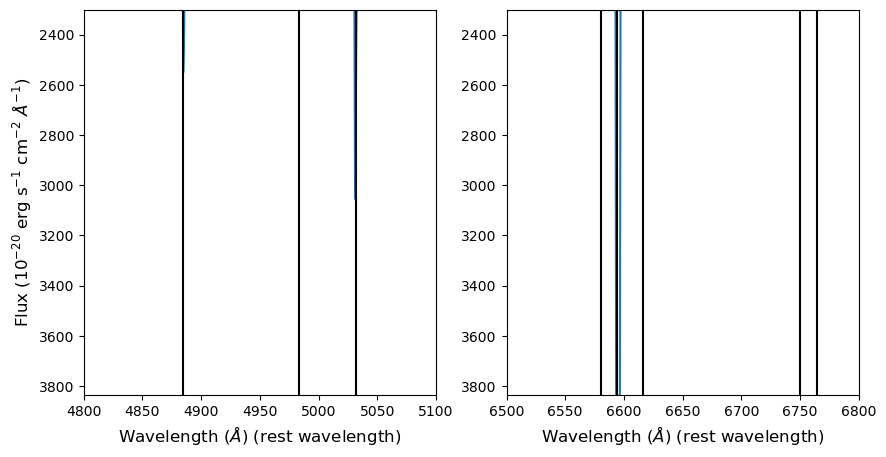

In [102]:
# Write plotting code for Region 2 here. 
fig,axs=plt.subplots(1,2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region2])
    for l,line in enumerate(em_lines):
        ax.axvline(lam_obs(em_lines[line],z),label=f'{line}',color='k') # correcting for redshift
    for s in sky_lines:
        ax.axvline(s,color='gray') # we don't need to correct these, because they are redshift 0
    ax.set_ylim(y,)
    ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12)
plt.savefig('__filename__',bbox_inches='tight')
print('Spectrum of Region 2 (with Emission Lines Labeled)')
plt.show()

### What do you notice about these spectra when comparing Region 1 and Region 2?

Region 1 has more emission lines than Region 2, but they both have an emission line at around 6584 nm, indicating that NII is in both regions (?).